# **Introduction to OPS via TIP - Lesson 1**

## 1. **What is OPS?**
This notebook provides a practicle introduction to the OPS Client library, part of the **Technology Intelligence Platform**, named **TIP** in short. The `OPSClient` class enables interaction with the European Patent Office's (EPO) **Open Patent Services (OPS) RESTful APIs** that offers machine-to-machine access to patent-related data via a standardised XML interface. While the **Open Patent Services (OPS)** system is a powerful tool designed for advanced patent data retrieval through its API, the EPO OPS library available in **TIP** enhances ease of users to access and download large volumes of data from the EPO's databases, develop tailor-made clients. <br>
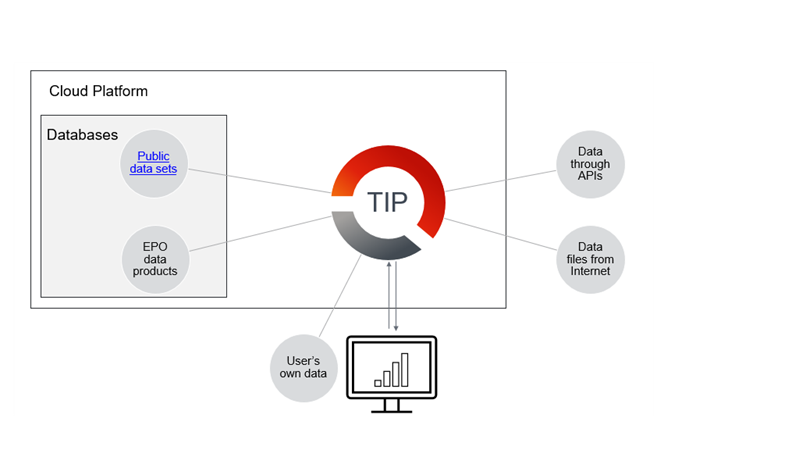 <br>
This notebook covers setting up the client in **TIP**, authenticating with OPS, and executing various API calls to retrieve patent data. It includes examples of use of the OPSClient for many common IP tasks. Below are key features and technical highlights of OPS as available in TIP.

### 1.1. **Key Features of OPS**

- **EPO Open Patent Services (OPS)**: A suite of web services provided by the EPO to access [patent information](https://www.epo.org/en/searching-for-patents/data/web-services/ops).
- **RESTful API**: An [API](https://www.ibm.com/topics/rest-apis) that follows the Representational State Transfer (REST) architectural style. 
- **Epodoc, Docdb**: Data structures working each with different patent document formats. Docdb format is suited to access Docdb, the EPO's master documentation database, containing  EPO worldwide bibliographic data, while Epodoc format is the format best suited for search of Docdb data.
- **Common Query Language (CQL)**: A query language designed specifically for searching patent databases, enabling efficient retrieval of relevant information.

### 1.2. **Data coverage**
OPS provides access to INPADOC, the EPO worldwide legal status database, containing a wide range of patent data related-information, which includes over 140 million patent documents from worldwide patent offices. This ensures consistency in:

- bibliographic data for over 90 juridictions,
- legal events for over 60 jurisdictions,
- full-text,
- images,
- legal status information,
- EP register data,
- EPO patent families,
- IPC and CPC classification data,
- Forward and backward citations.

### 1.3. **Search Capabilities**:
- Supports queries based on bibliographic information, legal status, and full-text search.
- Enables complex queries and retrieval of large volumes of patent information.

## 2. The OPS Client Library in TIP
### 2.1 Overview of the OPSClient Class
The OPSClient class provides methods to interact with various OPS services.
### 2.2 Key Concepts
To leverage OPS within TIP:
1. Set up authentication using your EPO credentials.
2. Use the OPS client library to interact with DOCDB and INPADOC datasets.
3. Retrieve patent data using Python scripts in Jupyter notebooks.
4. Process the data using pandas DataFrames for efficient manipulation and analysis.
5. Expand dataframe content to provide insights.
6. Visualize results using Python's data visualization libraries.
### 2.3 Benefits of Using OPS within TIP
This integrated approach allows for seamless patent data analysis, from retrieval to visualization, all within the TIP environment. It combines the power of EPO's vast patent databases with the flexibility and analytical capabilities of Python, making it an invaluable tool for patent researchers and analysts.

## 3. **Prerequisites and Setup**

### 3.1 OPS Account and Credentials
1. Ensure you have a working OPS account. Visit the [OPS Developer's Area](https://developers.epo.org/) and add a new application under "My Apps" to obtain your authentication credentials: `OPS_KEY` (Consumer Key) and `OPS_SECRET` (Consumer Secret Key).
2. Store these credentials in a `.env` file at the project root for easy access. This file can be edited using VS Code or a similar text editor.

Example `.env` file content:
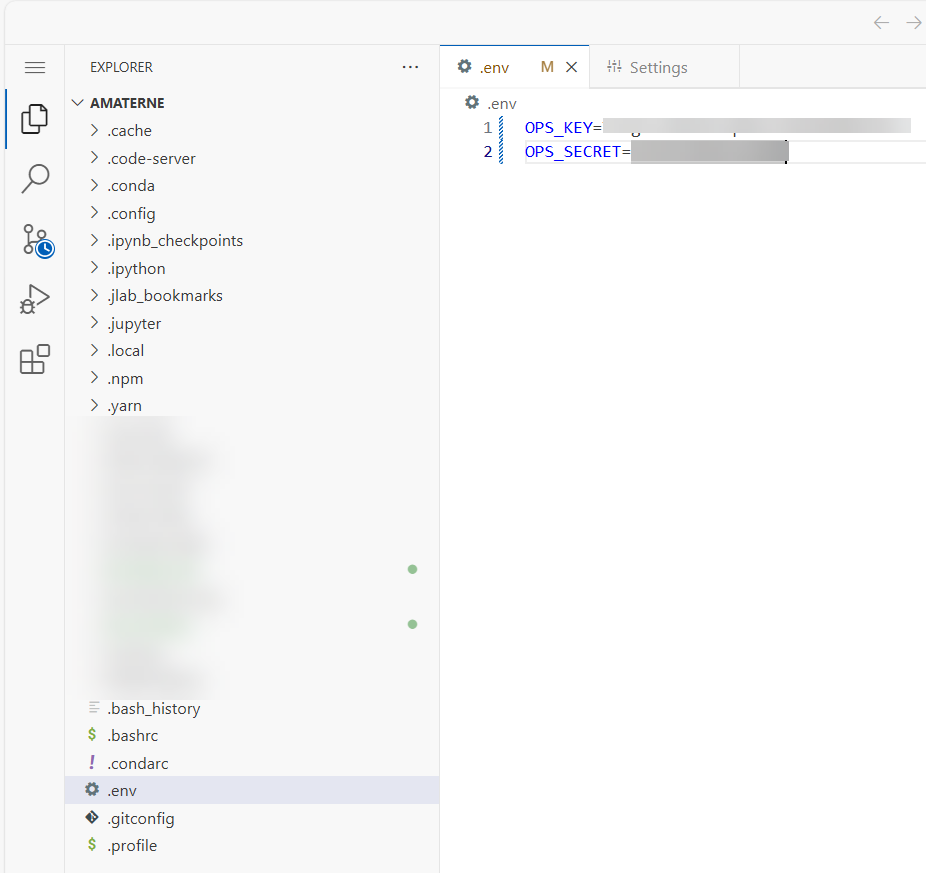

### 3.2 **Environment Setup (.env)**
The following code loads environment variables from the `.env` file, which includes your OPS credentials. It also sets up auto-reloading for the notebook to reflect any changes made to the modules.

In [1]:
# Python

%load_ext dotenv
%dotenv
%load_ext autoreload
%autoreload 2

* ```%``` is a magic command available in Jupyter notebooks used to trigger the notebook extensions ```dotenv``` and ```autoreload```.<br>
* They allow you to define sensitive information (like API keys or passwords) in a separate .env file, keeping them out of your code and improving security.<br>
* They automatically reload your notebook and any imported Python modules whenever changes are made, improving development efficiency.<br>

### 3.3 Library Installation and Import
The following code attempts to import necessary modules from `epo.tipdata.ops`. If these modules are not available, it installs the `epo-tipdata-ops` library. If Installation is done by default, no need to pip install it! A voir avec Carlos.

In [2]:
# Python

try:
    from epo.tipdata.ops import OPSClient, models, exceptions
except ImportError:
    import os
    os.system('pip install epo-tipdata-ops')
    from epo.tipdata.ops import OPSClient, models, exceptions

## 4. Getting Started with OPSClient

### 4.1 Initializing the Client
The OPSClient class provides methods to interact with various OPS services. You first need to create an instance of this class, providing your access token for authentication.
<!-- ```OPSClient(key, secret, accept_type='xml', middlewares=None)```<br><br>
This defines the constructor for the ```OPSClient``` class. It takes four arguments:<br>
* ```key```: (likely a string) Your EPO access key for authentication.<br>
* ```secret```: (likely a string) Your EPO access secret for authentication.<br>
* ```accept_type``` (optional, defaults to "xml"): The format you prefer for receiving data (e.g., "xml" or "json").<br>
* ```middlewares``` (optional, defaults to None): Potential middleware for additional functionalities during communication with EPO services.<br> -->

In [3]:
import os

client = OPSClient(
    key=os.getenv("OPS_KEY"), secret=os.getenv("OPS_SECRET")
)  # Instantiate client

## 5. **OPSClient Methods and Functionality**
The OPSClient class offers a large set of methods for retrieving patent data, enabling you to fetch specific details or conduct comprehensive searches. These provide functionalities for authentication, managing access tokens, and potentially defining service URLs.<br>

### 5.1 Overview of Available Methods
The ```help(client)``` command displays a detailed help documentation for the client object, which is an instance of the OPSClient class from the epo.tipdata.ops.client module. This class provides methods for interacting with the European Patent Office (EPO) data access services.<br>

In the TIP library, the OPSClient class is defined as a subclass of epo.tipdata.ops, inheriting its properties and methods to interact with the EPO's Open Patent Services.

### 5.2 Methods
The help output shows several methods available within the ```OPSClient``` class.<br>

1. ```published_data(reference_type, input, endpoint='biblio', constituents=None, output_type='raw')```: This method retrieves published data (bibliographic information, abstract, etc.) for a patent document.<br>
2. ```family(reference_type, input, constituents=None, output_type='raw')```: This method retrieves information about the extended patent family related to a provided document number.<br>
3. ```image(path, range=1, document_format='application/tiff')```: This method retrieves an image page for a specific document based on a path obtained from a previous published_data call.<br>
4. ```number(reference_type, input, output_format, output_type='raw')```: This method converts a patent number from one format (e.g., publication) to another (e.g., application).<br>
5. ```published_data_search(cql, range_begin=1, range_end=25, constituents=None, output_type='raw')```: This method allows searching for patent data using a CQL (Common Query Language) query.<br>
6. ```register(reference_type, input, constituents=None, output_type='raw')```: This method retrieves information from the European Patent Register for a specific patent document.<br>
7. ```register_search(cql, range_begin=1, range_end=25, output_type='raw')```: This method allows searching for data within the European Patent Register using a CQL query.<br>

## 6. Practical Examples
### 6.1 Retrieving Bibliographic Data of a granted patent
To retrieve a granted patent:

In [4]:
# fetch from Docdb EP1000000
biblio = client.published_data(                           # Retrieve bibliography data
    reference_type="publication",                         # publication, application, priority
    input=models.Docdb("1000000", "EP", "B1", date=None), # original, docdb, epodoc
    endpoint="biblio",                                    # optional, defaults to biblio in case of published_data
    constituents=[],                                      # optional, list of constituents
    output_type="Dataframe",                              # optional, xml or DataFrame format
)
display(biblio)

,system,family-id,country,doc-number,kind,bibliographic-data|publication-reference,bibliographic-data|classification-ipc,bibliographic-data|classifications-ipcr,bibliographic-data|patent-classifications,bibliographic-data|application-reference,bibliographic-data|priority-claims,bibliographic-data|parties,bibliographic-data|invention-title
0,ops.epo.org,19768124,EP,1000000,B1,{'document-id': [{'@document-id-type': 'docdb'...,"{'text': ['B28B5/02', 'B28B7/00', 'B28B1/29']}","{'classification-ipcr': [{'@sequence': '1', 't...","{'patent-classification': [{'@sequence': '1', ...","{'@doc-id': '17397285', 'document-id': [{'@doc...","{'priority-claim': {'@sequence': '1', '@kind':...",{'applicants': {'applicant': [{'@sequence': '1...,"[{'@lang': 'de', '#text': 'Vorrichtung zur Her..."


### 6.2 Retrieving Bibliographic Data of a non granted patent (A1) and of a granted patent (B1).
To retrieve a published patent with its different kind codes. For instance EP1000000 was published before examination with the kind code A1 before being granted:

In [5]:
# fetch from Docdb EP1000000
biblio = client.published_data(                           # Retrieve bibliography data
    reference_type="publication",                         # publication, application, priority
    input=models.Docdb("1000000", "EP", "%%", date=None), # original, docdb, epodoc
    endpoint="biblio",                                    # optional, defaults to biblio in case of published_data
    constituents=[],                                      # optional, list of constituents
    output_type="Dataframe",                              # optional, xml or DataFrame format
)
display(biblio)

,system,family-id,country,doc-number,kind,bibliographic-data,abstract
0,ops.epo.org,19768124,EP,1000000,A1,{'publication-reference': {'document-id': [{'@...,"{'@lang': 'en', 'p': 'The invention relates to..."
1,ops.epo.org,19768124,EP,1000000,B1,{'publication-reference': {'document-id': [{'@...,NaN
